In [1]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [2]:
# load data using functions coded in load_mnist.py
X_train = load_mnist.load_images(load_mnist.f_training_images)
y_train = load_mnist.load_labels(load_mnist.f_training_labels)

X_test = load_mnist.load_images(load_mnist.f_test_images)
y_test = load_mnist.load_labels(load_mnist.f_test_labels)

(60000, 784) (784,) (784, 784)


[]

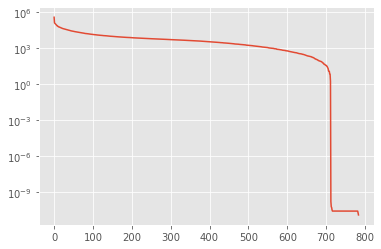

In [3]:
# investigate potential for a low-rank decomposition

U, S, VT = np.linalg.svd(X_train, full_matrices=False)

print(U.shape, S.shape, VT.shape)

plt.plot(range(len(S)),S)
plt.semilogy()

In [4]:
def train_lowrank_classifier(U, S, VT , y, r):
    """truncated SVD classifier for a match with the supplied digit
    the basic formula is w=(X.T@X)^(-1)X^Ty, but we create y as a membership matrix    
    """
    # create a matrix for y, where columns yj contain a 1 if yi=j, -1 if yi<>j
    y_mat = load_mnist.digit_2_matrix(y)
       
    # truncate the singular values to rank-r
    V = VT.T[:,:r]
    UT = U.T[:r,:]
    Sr = np.linalg.inv(np.diag(S[:r]))
    
    psuedo_inv = V@Sr@UT
    
    w = psuedo_inv@y_mat
    
    return w

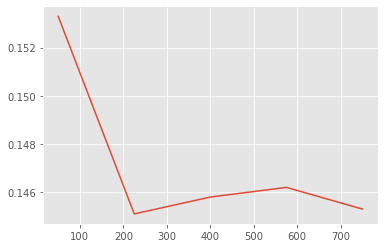

In [5]:
r_arr = np.linspace(50,750,5)
err_arr = np.zeros(5)

for i, r in enumerate(r_arr):
    w = train_lowrank_classifier(U, S, VT, y_train, int(r))
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    err_arr[i] = 1- np.sum(y_hat==y_test) / len(y_test)
    
plt.plot(r_arr, err_arr)